# Telecom Customer Churn — Modelling

## 1. Setup and data loading

In [36]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, FunctionTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors

X_train = pd.read_csv('Data/x_train.csv')
y_train = pd.read_csv('Data/y_train.csv')
X_test = pd.read_csv('Data/x_test.csv')
y_test = pd.read_csv('Data/y_test.csv')

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
X_train.head()

X_train shape: (5180, 32)
X_test shape: (1295, 32)


,Gender,Age,Married,Number of Dependents,Latitude,Longitude,Number of Referrals,Tenure in Months,Offer,Phone Service,...,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue
0,Male,35,Yes,3,36.545353,-119.338535,2,34,Offer C,No,...,Yes,Month-to-Month,Yes,Bank Withdrawal,44.85,1442.60,0.0,0,0.00,1442.60
1,Male,75,Yes,0,35.480896,-120.469476,7,68,Offer A,Yes,...,Yes,One Year,Yes,Credit Card,80.35,5589.30,0.0,0,2333.08,7922.38
2,Female,80,Yes,0,34.083086,-117.737997,1,43,No Offer,Yes,...,No,One Year,Yes,Bank Withdrawal,107.55,4533.90,0.0,140,595.12,5269.02
3,Male,44,No,0,34.049671,-117.468896,0,1,No Offer,No,...,Yes,Month-to-Month,Yes,Mailed Check,24.45,24.45,0.0,0,0.00,24.45
4,Female,75,Yes,1,38.148862,-121.737696,8,57,No Offer,Yes,...,Yes,Month-to-Month,Yes,Credit Card,95.30,5567.45,0.0,0,1610.25,7177.70


## 2. Preprocessing pipeline

### 2.1 Custom transformer: `Local_Churn_KNN_Score`

In [37]:
class LocalChurnKNNTransformer(BaseEstimator, TransformerMixin):
    """Distance-weighted local churn rate among a customer's K nearest neighbours,
    computed strictly within their own KMeans geographic region.

    fit(X, y)   -> learns regions + per-region neighbour pools from TRAINING data only
    transform(X)-> scores any data against those pools
                   (leave-one-out when X is the data fit() saw, full pool otherwise)
    """

    def __init__(self, n_regions=10, k=15, gamma=0.1, random_state=42):
        self.n_regions = n_regions
        self.k = k
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y):
        coords = X[['Latitude', 'Longitude']].values
        churn = np.asarray(y).ravel()

        self.kmeans_ = KMeans(n_clusters=self.n_regions,
                              random_state=self.random_state, n_init=10)
        region_labels = self.kmeans_.fit_predict(coords)

        # one neighbour pool per region, built from training rows only
        self.region_models_ = {}
        for region in np.unique(region_labels):
            mask = region_labels == region
            self.region_models_[region] = {
                'nn': NearestNeighbors(n_neighbors=min(self.k + 1, mask.sum())).fit(coords[mask]),
                'churn': churn[mask],
                'n': int(mask.sum()),
            }

        self._train_coords = coords
        self.fallback_rate_ = churn.mean()   # used if a region has no usable neighbours
        return self

    def transform(self, X):
        coords = X[['Latitude', 'Longitude']].values
        region_labels = self.kmeans_.predict(coords)

        # same rows as fit() -> self is in the pool and must be excluded
        is_train = (coords.shape == self._train_coords.shape) and np.allclose(coords, self._train_coords)

        scores = np.full(len(coords), np.nan)

        for region, m in self.region_models_.items():
            mask = region_labels == region
            if mask.sum() == 0:
                continue

            k_search = min(self.k + 1 if is_train else self.k, m['n'])
            distances, neighbor_idx = m['nn'].kneighbors(coords[mask], n_neighbors=k_search)

            if is_train and distances.shape[1] > 1:
                distances = distances[:, 1:]        # drop self (distance 0)
                neighbor_idx = neighbor_idx[:, 1:]

            # vectorised RBF weighting: closer neighbours count for more
            weights = np.exp(-self.gamma * distances ** 2)
            neigh_churn = m['churn'][neighbor_idx]

            denom = weights.sum(axis=1)
            safe = denom > 0
            region_scores = np.full(mask.sum(), self.fallback_rate_)
            region_scores[safe] = (weights * neigh_churn).sum(axis=1)[safe] / denom[safe]

            scores[mask] = region_scores

        # never emit NaN: downstream scalers/estimators cannot handle it
        scores = np.where(np.isnan(scores), self.fallback_rate_, scores)

        result = X.copy()
        result['Local_Churn_KNN_Score'] = scores
        return result

### 2.2 Column groups and encoding strategy

In [38]:
class ColumnDropper(BaseEstimator, TransformerMixin):
    """Drops specified columns. Used for IDs, leakage columns, and redundant features."""
    def __init__(self, columns):
        self.columns = columns

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.drop(columns=self.columns, errors='ignore')


# columns to drop entirely (ID, leakage, redundant-with-Tenure, high-cardinality geo)
drop_cols = ['Customer ID', 'Churn Category', 'Churn Reason', 'Total Charges']
geo_drop_cols = ['City', 'Zip Code']

# binary Yes/No columns (some with structural missing -> "No Phone/Internet Service")
binary_cols = ['Gender', 'Married', 'Phone Service', 'Multiple Lines',
               'Internet Service', 'Online Security', 'Online Backup',
               'Device Protection Plan', 'Premium Tech Support',
               'Streaming TV', 'Streaming Movies', 'Streaming Music',
               'Unlimited Data', 'Paperless Billing']

# nominal columns, few categories, no order
nominal_cols = ['Offer', 'Internet Type', 'Contract', 'Payment Method']

# all numeric columns (including our new engineered feature)
numeric_cols = ['Age', 'Number of Dependents', 'Number of Referrals', 'Tenure in Months',
                 'Avg Monthly Long Distance Charges', 'Avg Monthly GB Download',
                 'Monthly Charge', 'Total Refunds', 'Total Extra Data Charges',
                 'Total Long Distance Charges', 'Total Revenue', 'Local_Churn_KNN_Score']

# heavily right-skewed subset, flagged in EDA -> candidates for log1p
skewed_cols = ['Total Revenue', 'Total Long Distance Charges', 'Total Refunds',
               'Total Extra Data Charges', 'Avg Monthly GB Download']
non_skewed_numeric_cols = [c for c in numeric_cols if c not in skewed_cols]

binary_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('encoder', OrdinalEncoder())
])

nominal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

### 2.3 Pipeline builder

In [39]:
def build_pipeline(use_log_transform=True):
    """Builds the full preprocessing pipeline.
    use_log_transform=True applies log1p to the skewed numeric columns before scaling.
    Set to False later to compare model performance without it."""

    if use_log_transform:
        skewed_pipeline = Pipeline(steps=[
            ('log', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
            ('scaler', StandardScaler())
        ])
    else:
        skewed_pipeline = Pipeline(steps=[
            ('scaler', StandardScaler())
        ])

    plain_numeric_pipeline = Pipeline(steps=[
        ('scaler', StandardScaler())
    ])

    preprocessor = ColumnTransformer(transformers=[
        ('binary', binary_pipeline, binary_cols),
        ('nominal', nominal_pipeline, nominal_cols),
        ('numeric_skewed', skewed_pipeline, skewed_cols),
        ('numeric_plain', plain_numeric_pipeline, non_skewed_numeric_cols)
    ], remainder='drop')

    pipeline = Pipeline(steps=[
        ('drop_cols', ColumnDropper(drop_cols + geo_drop_cols)),
        ('geo_feature', LocalChurnKNNTransformer(n_regions=10, k=15, gamma=0.1)),
        ('preprocess', preprocessor)
    ])

    return pipeline

In [40]:
full_pipeline = build_pipeline(use_log_transform=True)

X_train_transformed = full_pipeline.fit_transform(X_train, y_train['Churn'])
X_test_transformed = full_pipeline.transform(X_test)

print("X_train_transformed shape:", X_train_transformed.shape)
print("X_test_transformed shape:", X_test_transformed.shape)

X_train_transformed shape: (5180, 42)
X_test_transformed shape: (1295, 42)


## 3. Exploratory single-split comparisons

### 3.1 Baseline logistic regression

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
log_reg.fit(X_train_transformed, y_train['Churn'])

y_pred = log_reg.predict(X_test_transformed)
y_pred_proba = log_reg.predict_proba(X_test_transformed)[:, 1]

print("Classification Report:")
print(classification_report(y_test['Churn'], y_pred))
print()
print("ROC-AUC:", roc_auc_score(y_test['Churn'], y_pred_proba))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test['Churn'], y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.83      0.89       927
           1       0.68      0.88      0.77       368

    accuracy                           0.85      1295
   macro avg       0.81      0.86      0.83      1295
weighted avg       0.87      0.85      0.85      1295


ROC-AUC: 0.9409678251489142

Confusion Matrix:
[[773 154]
 [ 44 324]]


### 3.2 Does the log transform help?

In [42]:
# Build and fit the non-log version, keeping every other setting identical
pipeline_nolog = build_pipeline(use_log_transform=False)

X_train_nolog = pipeline_nolog.fit_transform(X_train, y_train['Churn'])
X_test_nolog = pipeline_nolog.transform(X_test)

log_reg_nolog = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
log_reg_nolog.fit(X_train_nolog, y_train['Churn'])

y_pred_nolog = log_reg_nolog.predict(X_test_nolog)
y_pred_proba_nolog = log_reg_nolog.predict_proba(X_test_nolog)[:, 1]

# --- Side-by-side comparison ---
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

def get_metrics(y_true, y_pred, y_proba):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_proba),
        'Precision (Churn=1)': precision_score(y_true, y_pred, pos_label=1),
        'Recall (Churn=1)': recall_score(y_true, y_pred, pos_label=1),
        'F1 (Churn=1)': f1_score(y_true, y_pred, pos_label=1),
    }

metrics_with_log = get_metrics(y_test['Churn'], y_pred, y_pred_proba)
metrics_without_log = get_metrics(y_test['Churn'], y_pred_nolog, y_pred_proba_nolog)

comparison = pd.DataFrame({
    'With Log-Transform': metrics_with_log,
    'Without Log-Transform': metrics_without_log
})
comparison['Difference'] = comparison['With Log-Transform'] - comparison['Without Log-Transform']

print(comparison.round(4))
print()
print("Confusion Matrix — WITH log-transform:")
print(confusion_matrix(y_test['Churn'], y_pred))
print()
print("Confusion Matrix — WITHOUT log-transform:")
print(confusion_matrix(y_test['Churn'], y_pred_nolog))

                     With Log-Transform  Without Log-Transform  Difference
Accuracy                         0.8471                 0.8347      0.0124
ROC-AUC                          0.9410                 0.9279      0.0130
Precision (Churn=1)              0.6778                 0.6540      0.0238
Recall (Churn=1)                 0.8804                 0.8886     -0.0082
F1 (Churn=1)                     0.7660                 0.7535      0.0125

Confusion Matrix — WITH log-transform:
[[773 154]
 [ 44 324]]

Confusion Matrix — WITHOUT log-transform:
[[754 173]
 [ 41 327]]


### 3.3 Random forest and XGBoost

In [43]:
from sklearn.ensemble import RandomForestClassifier

# Using the log-transform version (X_train_transformed / X_test_transformed) for consistency,
# though as discussed, trees are generally insensitive to monotonic transforms like log1p
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train_transformed, y_train['Churn'])

y_pred_rf = rf.predict(X_test_transformed)
y_pred_proba_rf = rf.predict_proba(X_test_transformed)[:, 1]

metrics_rf = get_metrics(y_test['Churn'], y_pred_rf, y_pred_proba_rf)

comparison_models = pd.DataFrame({
    'Logistic Regression (log)': metrics_with_log,
    'Random Forest': metrics_rf
})
comparison_models['Difference'] = comparison_models['Random Forest'] - comparison_models['Logistic Regression (log)']

print(comparison_models.round(4))
print()
print("Classification Report — Random Forest:")
print(classification_report(y_test['Churn'], y_pred_rf))
print()
print("Confusion Matrix — Random Forest:")
print(confusion_matrix(y_test['Churn'], y_pred_rf))

                     Logistic Regression (log)  Random Forest  Difference
Accuracy                                0.8471         0.8741      0.0270
ROC-AUC                                 0.9410         0.9421      0.0011
Precision (Churn=1)                     0.6778         0.7676      0.0898
Recall (Churn=1)                        0.8804         0.7989     -0.0815
F1 (Churn=1)                            0.7660         0.7830      0.0170

Classification Report — Random Forest:
              precision    recall  f1-score   support

           0       0.92      0.90      0.91       927
           1       0.77      0.80      0.78       368

    accuracy                           0.87      1295
   macro avg       0.84      0.85      0.85      1295
weighted avg       0.88      0.87      0.87      1295


Confusion Matrix — Random Forest:
[[838  89]
 [ 74 294]]


### 3.4 Threshold sensitivity

In [44]:
# 1. Predicted probabilities already computed as y_pred_proba_rf in Cell 8

# 2 & 3. Evaluate a range of thresholds
thresholds = np.arange(0.20, 0.71, 0.02)

threshold_results = []
for t in thresholds:
    y_pred_t = (y_pred_proba_rf >= t).astype(int)
    threshold_results.append({
        'Threshold': round(t, 2),
        'Precision': precision_score(y_test['Churn'], y_pred_t, pos_label=1, zero_division=0),
        'Recall': recall_score(y_test['Churn'], y_pred_t, pos_label=1, zero_division=0),
        'F1': f1_score(y_test['Churn'], y_pred_t, pos_label=1, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)
print(threshold_df.round(4).to_string(index=False))

 Threshold  Precision  Recall     F1
      0.20     0.5333  0.9783 0.6903
      0.22     0.5569  0.9701 0.7076
      0.24     0.5740  0.9592 0.7182
      0.26     0.5885  0.9484 0.7263
      0.28     0.6004  0.9266 0.7286
      0.30     0.6227  0.9239 0.7440
      0.32     0.6393  0.9103 0.7511
      0.34     0.6529  0.8995 0.7566
      0.36     0.6626  0.8859 0.7581
      0.38     0.6772  0.8723 0.7625
      0.40     0.7026  0.8668 0.7762
      0.42     0.7143  0.8560 0.7787
      0.44     0.7254  0.8397 0.7783
      0.46     0.7415  0.8342 0.7852
      0.48     0.7575  0.8234 0.7891
      0.50     0.7629  0.8043 0.7831
      0.52     0.7871  0.7935 0.7903
      0.54     0.8091  0.7717 0.7900
      0.56     0.8192  0.7636 0.7904
      0.58     0.8359  0.7473 0.7891
      0.60     0.8516  0.7174 0.7788
      0.62     0.8591  0.6957 0.7688
      0.64     0.8679  0.6603 0.7500
      0.66     0.8855  0.6304 0.7365
      0.68     0.8960  0.6087 0.7249
      0.70     0.9174  0.5734 0.7057


In [45]:
target_recall = 0.88

threshold_df['Recall_Diff'] = (threshold_df['Recall'] - target_recall).abs()
best_row = threshold_df.loc[threshold_df['Recall_Diff'].idxmin()]

selected_threshold = best_row['Threshold']
print(f"Selected threshold: {selected_threshold}")
print(f"Recall: {best_row['Recall']:.4f}")
print(f"Precision: {best_row['Precision']:.4f}")
print(f"F1: {best_row['F1']:.4f}")
print()

y_pred_rf_tuned = (y_pred_proba_rf >= selected_threshold).astype(int)
print("Confusion Matrix at selected threshold:")
print(confusion_matrix(y_test['Churn'], y_pred_rf_tuned))
print()

# 6. Compare against Logistic Regression baseline
comparison_final = pd.DataFrame({
    'Logistic Regression (t=0.50)': metrics_with_log,
    f'Random Forest (t={selected_threshold})': {
        'Accuracy': accuracy_score(y_test['Churn'], y_pred_rf_tuned),
        'ROC-AUC': roc_auc_score(y_test['Churn'], y_pred_proba_rf),
        'Precision (Churn=1)': precision_score(y_test['Churn'], y_pred_rf_tuned, pos_label=1),
        'Recall (Churn=1)': recall_score(y_test['Churn'], y_pred_rf_tuned, pos_label=1),
        'F1 (Churn=1)': f1_score(y_test['Churn'], y_pred_rf_tuned, pos_label=1),
    }
})
comparison_final['Difference'] = comparison_final.iloc[:, 1] - comparison_final.iloc[:, 0]
print(comparison_final.round(4))

Selected threshold: 0.36
Recall: 0.8859
Precision: 0.6626
F1: 0.7581

Confusion Matrix at selected threshold:
[[761 166]
 [ 42 326]]

                     Logistic Regression (t=0.50)  Random Forest (t=0.36)  \
Accuracy                                   0.8471                  0.8394   
ROC-AUC                                    0.9410                  0.9421   
Precision (Churn=1)                        0.6778                  0.6626   
Recall (Churn=1)                           0.8804                  0.8859   
F1 (Churn=1)                               0.7660                  0.7581   

                     Difference  
Accuracy                -0.0077  
ROC-AUC                  0.0011  
Precision (Churn=1)     -0.0152  
Recall (Churn=1)         0.0054  
F1 (Churn=1)            -0.0078  


### 3.5 Logistic regression coefficients

In [46]:
# 1. Extract feature names after preprocessing
feature_names = full_pipeline.named_steps['preprocess'].get_feature_names_out()

# clean up the auto-generated prefixes (binary__, nominal__, numeric_skewed__, numeric_plain__)
clean_names = [name.split('__', 1)[1] if '__' in name else name for name in feature_names]

# 2. Extract coefficients
coefs = log_reg.coef_[0]

# 3. Build the table with odds ratios
coef_df = pd.DataFrame({
    'Feature': clean_names,
    'Coefficient': coefs,
    'Odds_Ratio': np.exp(coefs)
})

# 4. Sort by absolute coefficient value
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False).drop(columns='Abs_Coefficient')

pd.set_option('display.max_rows', None)
print(coef_df.round(4).to_string(index=False))

                          Feature  Coefficient  Odds_Ratio
                   Monthly Charge       2.0927      8.1070
                    Total Revenue      -2.0451      0.1294
                          Married       1.5391      4.6603
              Number of Referrals      -1.4718      0.2295
                Contract_Two Year      -1.3591      0.2569
          Contract_Month-to-Month       1.2870      3.6218
                 Tenure in Months       0.9467      2.5771
        Internet Type_Fiber Optic      -0.6777      0.5078
                 Internet Service      -0.6343      0.5303
            Local_Churn_KNN_Score       0.6084      1.8374
             Number of Dependents      -0.6083      0.5443
Internet Type_No Internet Service       0.5706      1.7694
                    Phone Service      -0.4598      0.6314
Avg Monthly Long Distance Charges       0.4245      1.5288
       Payment Method_Credit Card      -0.3469      0.7069
      Total Long Distance Charges      -0.3312      0.71

In [47]:
from xgboost import XGBClassifier

# scale_pos_weight is XGBoost's equivalent of class_weight='balanced':
# ratio of negative to positive class counts, to handle the 71.6/28.4 imbalance
scale_pos_weight = (y_train['Churn'] == 0).sum() / (y_train['Churn'] == 1).sum()

xgb = XGBClassifier(
    n_estimators=200,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train_transformed, y_train['Churn'])

y_pred_xgb = xgb.predict(X_test_transformed)
y_pred_proba_xgb = xgb.predict_proba(X_test_transformed)[:, 1]

metrics_xgb = get_metrics(y_test['Churn'], y_pred_xgb, y_pred_proba_xgb)

comparison_all = pd.DataFrame({
    'Logistic Regression': metrics_with_log,
    'Random Forest (t=0.50)': metrics_rf,
    'XGBoost (t=0.50)': metrics_xgb
})

print(comparison_all.round(4))
print()
print("Classification Report — XGBoost:")
print(classification_report(y_test['Churn'], y_pred_xgb))
print()
print("Confusion Matrix — XGBoost:")
print(confusion_matrix(y_test['Churn'], y_pred_xgb))

                     Logistic Regression  Random Forest (t=0.50)  \
Accuracy                          0.8471                  0.8741   
ROC-AUC                           0.9410                  0.9421   
Precision (Churn=1)               0.6778                  0.7676   
Recall (Churn=1)                  0.8804                  0.7989   
F1 (Churn=1)                      0.7660                  0.7830   

                     XGBoost (t=0.50)  
Accuracy                       0.8718  
ROC-AUC                        0.9358  
Precision (Churn=1)            0.7760  
Recall (Churn=1)               0.7717  
F1 (Churn=1)                   0.7738  

Classification Report — XGBoost:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91       927
           1       0.78      0.77      0.77       368

    accuracy                           0.87      1295
   macro avg       0.84      0.84      0.84      1295
weighted avg       0.87      0.87      0.87  

### 3.6 Comparing all three models at matched recall

In [48]:
thresholds_xgb = np.arange(0.10, 0.71, 0.02)

threshold_results_xgb = []
for t in thresholds_xgb:
    y_pred_t = (y_pred_proba_xgb >= t).astype(int)
    threshold_results_xgb.append({
        'Threshold': round(t, 2),
        'Precision': precision_score(y_test['Churn'], y_pred_t, pos_label=1, zero_division=0),
        'Recall': recall_score(y_test['Churn'], y_pred_t, pos_label=1, zero_division=0),
        'F1': f1_score(y_test['Churn'], y_pred_t, pos_label=1, zero_division=0)
    })

threshold_df_xgb = pd.DataFrame(threshold_results_xgb)

target_recall = 0.88
threshold_df_xgb['Recall_Diff'] = (threshold_df_xgb['Recall'] - target_recall).abs()
best_row_xgb = threshold_df_xgb.loc[threshold_df_xgb['Recall_Diff'].idxmin()]

selected_threshold_xgb = best_row_xgb['Threshold']
print(threshold_df_xgb.round(4).to_string(index=False))
print()
print(f"Selected threshold: {selected_threshold_xgb}")
print(f"Recall: {best_row_xgb['Recall']:.4f}")
print(f"Precision: {best_row_xgb['Precision']:.4f}")
print(f"F1: {best_row_xgb['F1']:.4f}")
print()

y_pred_xgb_tuned = (y_pred_proba_xgb >= selected_threshold_xgb).astype(int)
print("Confusion Matrix at selected threshold:")
print(confusion_matrix(y_test['Churn'], y_pred_xgb_tuned))
print()

# Final 3-way comparison, all matched at ~0.88 recall
comparison_matched = pd.DataFrame({
    'Logistic Regression (t=0.50)': metrics_with_log,
    f'Random Forest (t={selected_threshold})': {
        'Accuracy': accuracy_score(y_test['Churn'], y_pred_rf_tuned),
        'ROC-AUC': roc_auc_score(y_test['Churn'], y_pred_proba_rf),
        'Precision (Churn=1)': precision_score(y_test['Churn'], y_pred_rf_tuned, pos_label=1),
        'Recall (Churn=1)': recall_score(y_test['Churn'], y_pred_rf_tuned, pos_label=1),
        'F1 (Churn=1)': f1_score(y_test['Churn'], y_pred_rf_tuned, pos_label=1),
    },
    f'XGBoost (t={selected_threshold_xgb})': {
        'Accuracy': accuracy_score(y_test['Churn'], y_pred_xgb_tuned),
        'ROC-AUC': roc_auc_score(y_test['Churn'], y_pred_proba_xgb),
        'Precision (Churn=1)': precision_score(y_test['Churn'], y_pred_xgb_tuned, pos_label=1),
        'Recall (Churn=1)': recall_score(y_test['Churn'], y_pred_xgb_tuned, pos_label=1),
        'F1 (Churn=1)': f1_score(y_test['Churn'], y_pred_xgb_tuned, pos_label=1),
    }
})
print(comparison_matched.round(4))

 Threshold  Precision  Recall     F1  Recall_Diff
      0.10     0.6547  0.8913 0.7549       0.0113
      0.12     0.6694  0.8804 0.7606       0.0004
      0.14     0.6815  0.8723 0.7652       0.0077
      0.16     0.6911  0.8696 0.7702       0.0104
      0.18     0.6982  0.8614 0.7713       0.0186
      0.20     0.7079  0.8560 0.7749       0.0240
      0.22     0.7114  0.8505 0.7748       0.0295
      0.24     0.7149  0.8451 0.7746       0.0349
      0.26     0.7199  0.8451 0.7775       0.0349
      0.28     0.7254  0.8397 0.7783       0.0403
      0.30     0.7279  0.8288 0.7751       0.0512
      0.32     0.7324  0.8179 0.7728       0.0621
      0.34     0.7414  0.8179 0.7778       0.0621
      0.36     0.7444  0.8071 0.7744       0.0729
      0.38     0.7519  0.7989 0.7747       0.0811
      0.40     0.7578  0.7908 0.7739       0.0892
      0.42     0.7632  0.7880 0.7754       0.0920
      0.44     0.7666  0.7853 0.7758       0.0947
      0.46     0.7680  0.7826 0.7752       0.0974


### 3.7 Candidate engineered features

In [49]:
class InteractionFeatureAdder(BaseEstimator, TransformerMixin):
    """Adds Tenure_x_MonthToMonth = Tenure in Months if Contract is Month-to-Month, else 0.
    Captures the idea that tenure's protective effect is conditional on having no contract lock-in."""
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        result = X.copy()
        is_mtm = (result['Contract'] == 'Month-to-Month').astype(int)
        result['Tenure_x_MTM'] = result['Tenure in Months'] * is_mtm
        return result

In [50]:
# insert the new interaction step right after the geo feature, before column encoding
new_numeric_cols = non_skewed_numeric_cols + ['Tenure_x_MTM']

def build_pipeline_v2(use_log_transform=True):
    if use_log_transform:
        skewed_pipeline = Pipeline(steps=[
            ('log', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
            ('scaler', StandardScaler())
        ])
    else:
        skewed_pipeline = Pipeline(steps=[('scaler', StandardScaler())])

    plain_numeric_pipeline = Pipeline(steps=[('scaler', StandardScaler())])

    preprocessor_v2 = ColumnTransformer(transformers=[
        ('binary', binary_pipeline, binary_cols),
        ('nominal', nominal_pipeline, nominal_cols),
        ('numeric_skewed', skewed_pipeline, skewed_cols),
        ('numeric_plain', plain_numeric_pipeline, new_numeric_cols)
    ], remainder='drop')

    pipeline = Pipeline(steps=[
        ('drop_cols', ColumnDropper(drop_cols + geo_drop_cols)),
        ('geo_feature', LocalChurnKNNTransformer(n_regions=10, k=15, gamma=0.1)),
        ('interaction', InteractionFeatureAdder()),
        ('preprocess', preprocessor_v2)
    ])
    return pipeline

In [51]:
pipeline_v2 = build_pipeline_v2(use_log_transform=True)

X_train_v2 = pipeline_v2.fit_transform(X_train, y_train['Churn'])
X_test_v2 = pipeline_v2.transform(X_test)

log_reg_v2 = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
log_reg_v2.fit(X_train_v2, y_train['Churn'])

y_pred_v2 = log_reg_v2.predict(X_test_v2)
y_pred_proba_v2 = log_reg_v2.predict_proba(X_test_v2)[:, 1]

metrics_v2 = get_metrics(y_test['Churn'], y_pred_v2, y_pred_proba_v2)

# 6. Compare against the original baseline
comparison_feature1 = pd.DataFrame({
    'Baseline (no interaction)': metrics_with_log,
    'With Tenure_x_MTM': metrics_v2
})
comparison_feature1['Difference'] = comparison_feature1['With Tenure_x_MTM'] - comparison_feature1['Baseline (no interaction)']
print(comparison_feature1.round(4))

                     Baseline (no interaction)  With Tenure_x_MTM  Difference
Accuracy                                0.8471             0.8486      0.0015
ROC-AUC                                 0.9410             0.9413      0.0003
Precision (Churn=1)                     0.6778             0.6807      0.0028
Recall (Churn=1)                        0.8804             0.8804      0.0000
F1 (Churn=1)                            0.7660             0.7678      0.0018


In [52]:
class NewCustomerFlagAdder(BaseEstimator, TransformerMixin):
    """Flags customers still within their first 12 months as higher-risk,
    capturing the 'new customer cliff' pattern seen in Tenure vs Churn."""
    def __init__(self, threshold_months=12):
        self.threshold_months = threshold_months

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        result = X.copy()
        result['Is_New_Customer'] = (result['Tenure in Months'] <= self.threshold_months).astype(int)
        return result

In [53]:
new_binary_cols = binary_cols + ['Is_New_Customer']

def build_pipeline_v3(use_log_transform=True):
    if use_log_transform:
        skewed_pipeline = Pipeline(steps=[
            ('log', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
            ('scaler', StandardScaler())
        ])
    else:
        skewed_pipeline = Pipeline(steps=[('scaler', StandardScaler())])

    plain_numeric_pipeline = Pipeline(steps=[('scaler', StandardScaler())])

    # Is_New_Customer is already 0/1, so it just needs to pass through -
    # we add it via a small binary sub-pipeline (no imputation needed, no missing values possible)
    new_flag_pipeline = Pipeline(steps=[('passthrough', FunctionTransformer())])

    preprocessor_v3 = ColumnTransformer(transformers=[
        ('binary', binary_pipeline, binary_cols),
        ('new_flag', new_flag_pipeline, ['Is_New_Customer']),
        ('nominal', nominal_pipeline, nominal_cols),
        ('numeric_skewed', skewed_pipeline, skewed_cols),
        ('numeric_plain', plain_numeric_pipeline, non_skewed_numeric_cols)
    ], remainder='drop')

    pipeline = Pipeline(steps=[
        ('drop_cols', ColumnDropper(drop_cols + geo_drop_cols)),
        ('geo_feature', LocalChurnKNNTransformer(n_regions=10, k=15, gamma=0.1)),
        ('new_customer_flag', NewCustomerFlagAdder(threshold_months=12)),
        ('preprocess', preprocessor_v3)
    ])
    return pipeline

In [54]:
pipeline_v3 = build_pipeline_v3(use_log_transform=True)

X_train_v3 = pipeline_v3.fit_transform(X_train, y_train['Churn'])
X_test_v3 = pipeline_v3.transform(X_test)

log_reg_v3 = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
log_reg_v3.fit(X_train_v3, y_train['Churn'])

y_pred_v3 = log_reg_v3.predict(X_test_v3)
y_pred_proba_v3 = log_reg_v3.predict_proba(X_test_v3)[:, 1]

metrics_v3 = get_metrics(y_test['Churn'], y_pred_v3, y_pred_proba_v3)

comparison_feature2 = pd.DataFrame({
    'Baseline (no new features)': metrics_with_log,
    'With Is_New_Customer': metrics_v3
})
comparison_feature2['Difference'] = comparison_feature2['With Is_New_Customer'] - comparison_feature2['Baseline (no new features)']
print(comparison_feature2.round(4))

                     Baseline (no new features)  With Is_New_Customer  \
Accuracy                                 0.8471                0.8463   
ROC-AUC                                  0.9410                0.9408   
Precision (Churn=1)                      0.6778                0.6786   
Recall (Churn=1)                         0.8804                0.8723   
F1 (Churn=1)                             0.7660                0.7634   

                     Difference  
Accuracy                -0.0008  
ROC-AUC                 -0.0002  
Precision (Churn=1)      0.0008  
Recall (Churn=1)        -0.0082  
F1 (Churn=1)            -0.0026  


# 4. Cross-validated model comparison

In [55]:
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from xgboost import XGBClassifier

# One shared CV object -> identical folds for every experiment in this notebook.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scale_pos_weight = (y_train['Churn'] == 0).sum() / (y_train['Churn'] == 1).sum()
print(f"scale_pos_weight (neg/pos ratio): {scale_pos_weight:.3f}")


def make_model_pipeline(classifier, feature_version='baseline', use_log_transform=True):
    """Preprocessing + classifier as ONE estimator.

    Building it this way is what makes cross-validation honest: passing this object to
    cross_validate / GridSearchCV refits every preprocessing step inside each fold.
    """
    builders = {
        'baseline':     build_pipeline,
        'tenure_mtm':   build_pipeline_v2,
        'new_customer': build_pipeline_v3,
    }
    base = builders[feature_version](use_log_transform=use_log_transform)
    return Pipeline(steps=base.steps + [('classifier', clone(classifier))])


MODELS = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    'Random Forest':       RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=200, scale_pos_weight=scale_pos_weight,
                                         random_state=42, eval_metric='logloss'),
}

scale_pos_weight (neg/pos ratio): 2.521


## 4.1 Baseline cross-validated scores

In [56]:
scoring = ['roc_auc', 'precision', 'recall', 'f1']
cv_results = {}
baseline_fold_auc = {}

for name, model in MODELS.items():
    pipe = make_model_pipeline(model)                       # preprocessing refit per fold
    scores = cross_validate(pipe, X_train, y_train['Churn'],
                            cv=cv, scoring=scoring, n_jobs=1)

    baseline_fold_auc[name] = scores['test_roc_auc']
    cv_results[name] = {
        'ROC-AUC (mean)':   scores['test_roc_auc'].mean(),
        'ROC-AUC (std)':    scores['test_roc_auc'].std(),
        'Precision (mean)': scores['test_precision'].mean(),
        'Recall (mean)':    scores['test_recall'].mean(),
        'F1 (mean)':        scores['test_f1'].mean(),
    }

    print(f"--- {name} ---")
    print(f"  ROC-AUC : {scores['test_roc_auc'].mean():.4f} +/- {scores['test_roc_auc'].std():.4f}"
          f"  folds={np.round(scores['test_roc_auc'], 4)}")
    print(f"  Precision: {scores['test_precision'].mean():.4f}"
          f" | Recall: {scores['test_recall'].mean():.4f}"
          f" | F1: {scores['test_f1'].mean():.4f}")
    print()

cv_baseline_summary = pd.DataFrame(cv_results).T
print(cv_baseline_summary.round(4))

--- Logistic Regression ---
  ROC-AUC : 0.9211 +/- 0.0091  folds=[0.9073 0.9243 0.9305 0.9296 0.9138]
  Precision: 0.6559 | Recall: 0.8409 | F1: 0.7369

--- Random Forest ---
  ROC-AUC : 0.9219 +/- 0.0069  folds=[0.9134 0.9222 0.9295 0.9293 0.9149]
  Precision: 0.7536 | Recall: 0.7546 | F1: 0.7541

--- XGBoost ---
  ROC-AUC : 0.9165 +/- 0.0046  folds=[0.9204 0.9097 0.9228 0.9146 0.915 ]
  Precision: 0.7691 | Recall: 0.7369 | F1: 0.7525

                     ROC-AUC (mean)  ROC-AUC (std)  Precision (mean)  \
Logistic Regression          0.9211         0.0091            0.6559   
Random Forest                0.9219         0.0069            0.7536   
XGBoost                      0.9165         0.0046            0.7691   

                     Recall (mean)  F1 (mean)  
Logistic Regression         0.8409     0.7369  
Random Forest               0.7546     0.7541  
XGBoost                     0.7369     0.7525  


## 4.2 Fold-to-fold variability

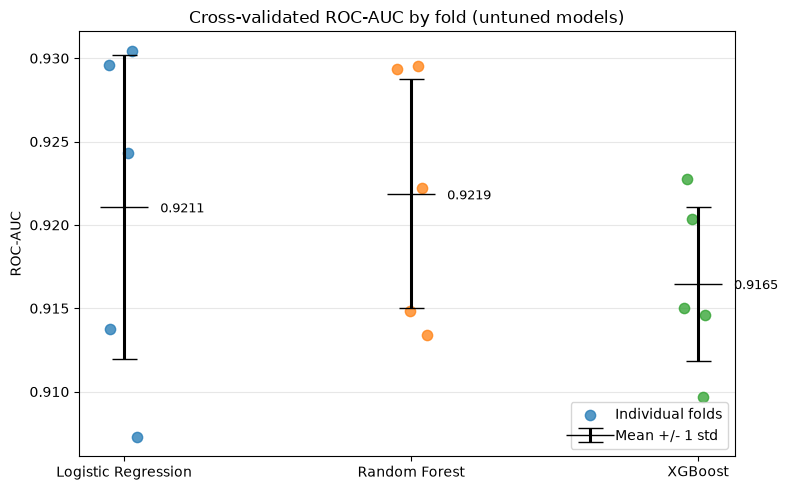

In [57]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
names = list(baseline_fold_auc.keys())

for i, name in enumerate(names):
    folds = baseline_fold_auc[name]
    # individual folds, jittered slightly so overlapping points stay visible
    ax.scatter(np.full_like(folds, i) + np.random.uniform(-0.06, 0.06, len(folds)),
               folds, s=55, alpha=0.75, zorder=3, label='Individual folds' if i == 0 else None)
    # mean +/- 1 std
    ax.errorbar(i, folds.mean(), yerr=folds.std(), fmt='_', markersize=34,
                capsize=9, linewidth=2.2, color='black', zorder=4,
                label='Mean +/- 1 std' if i == 0 else None)
    ax.annotate(f"{folds.mean():.4f}", (i, folds.mean()),
                textcoords="offset points", xytext=(26, -4), fontsize=9)

ax.set_xticks(range(len(names)))
ax.set_xticklabels(names)
ax.set_ylabel('ROC-AUC')
ax.set_title('Cross-validated ROC-AUC by fold (untuned models)')
ax.grid(axis='y', alpha=0.3)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

# 5. Cross-validated re-test of the engineered features

In [58]:
rf_template = MODELS['Random Forest']

def cv_auc(feature_version, label):
    pipe = make_model_pipeline(rf_template, feature_version=feature_version)
    aucs = cross_validate(pipe, X_train, y_train['Churn'],
                          cv=cv, scoring=['roc_auc'], n_jobs=1)['test_roc_auc']
    print(f"--- {label} ---")
    print(f"  Fold ROC-AUCs: {np.round(aucs, 4)}")
    print(f"  Mean: {aucs.mean():.4f}   Std: {aucs.std():.4f}\n")
    return aucs

base_aucs = cv_auc('baseline',     'Random Forest - baseline')
mtm_aucs  = cv_auc('tenure_mtm',   'Random Forest + Tenure_x_MTM')
new_aucs  = cv_auc('new_customer', 'Random Forest + Is_New_Customer')

for label, aucs in [('Tenure_x_MTM', mtm_aucs), ('Is_New_Customer', new_aucs)]:
    d = aucs - base_aucs
    print(f"{label:>16}: mean diff {d.mean():+.4f} | per-fold {np.round(d, 4)} "
          f"| folds improved: {(d > 0).sum()}/5")

--- Random Forest - baseline ---
  Fold ROC-AUCs: [0.9134 0.9222 0.9295 0.9293 0.9149]
  Mean: 0.9219   Std: 0.0069

--- Random Forest + Tenure_x_MTM ---
  Fold ROC-AUCs: [0.9099 0.9214 0.9258 0.9316 0.9115]
  Mean: 0.9200   Std: 0.0083

--- Random Forest + Is_New_Customer ---
  Fold ROC-AUCs: [0.9144 0.922  0.9272 0.9278 0.9157]
  Mean: 0.9214   Std: 0.0056

    Tenure_x_MTM: mean diff -0.0018 | per-fold [-0.0035 -0.0008 -0.0037  0.0022 -0.0034] | folds improved: 1/5
 Is_New_Customer: mean diff -0.0005 | per-fold [ 0.001  -0.0002 -0.0024 -0.0015  0.0009] | folds improved: 2/5


### Decision: both features are **removed**

# 6. Hyperparameter tuning by cross-validation

## 6.1 Logistic regression

In [59]:
param_grid_lr = {
    'classifier__C':       [0.01, 0.1, 1.0, 10.0],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver':  ['saga'],          # saga supports both l1 and l2
}

search_lr = GridSearchCV(
    estimator=make_model_pipeline(MODELS['Logistic Regression']),
    param_grid=param_grid_lr,
    scoring='roc_auc',
    cv=cv,                 # same folds as the baseline
    n_jobs=1,
    refit=True,            # refit best config on the full training set
    verbose=1,
)
search_lr.fit(X_train, y_train['Churn'])       # training data only

print("Best params:", search_lr.best_params_)
print(f"Best CV ROC-AUC: {search_lr.best_score_:.4f}")
print(f"Baseline CV ROC-AUC: {baseline_fold_auc['Logistic Regression'].mean():.4f}")
print(f"Improvement: {search_lr.best_score_ - baseline_fold_auc['Logistic Regression'].mean():+.4f}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits


c:\Users\Bahar\Documents\GitHub\customer-churn-prediction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Bahar\Documents\GitHub\customer-churn-prediction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\Bahar\Documents\GitHub\customer-churn-prediction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalt

Best params: {'classifier__C': 1.0, 'classifier__penalty': 'l1', 'classifier__solver': 'saga'}
Best CV ROC-AUC: 0.9211
Baseline CV ROC-AUC: 0.9211
Improvement: +0.0000


## 6.2 Random forest

In [60]:
param_dist_rf = {
    'classifier__n_estimators':      [200, 400, 600],
    'classifier__max_depth':         [None, 8, 12, 16, 24],
    'classifier__min_samples_split': [2, 5, 10, 20],
    'classifier__min_samples_leaf':  [1, 2, 4, 8],
    'classifier__max_features':      ['sqrt', 'log2', 0.4],
    'classifier__class_weight':      ['balanced', 'balanced_subsample'],
}

search_rf = RandomizedSearchCV(
    estimator=make_model_pipeline(RandomForestClassifier(random_state=42)),
    param_distributions=param_dist_rf,
    n_iter=20,
    scoring='roc_auc',
    cv=cv,
    n_jobs=1,
    refit=True,
    random_state=42,
    verbose=1,
)
search_rf.fit(X_train, y_train['Churn'])

print("Best params:", search_rf.best_params_)
print(f"Best CV ROC-AUC: {search_rf.best_score_:.4f}")
print(f"Baseline CV ROC-AUC: {baseline_fold_auc['Random Forest'].mean():.4f}")
print(f"Improvement: {search_rf.best_score_ - baseline_fold_auc['Random Forest'].mean():+.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'classifier__n_estimators': 400, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 1, 'classifier__max_features': 0.4, 'classifier__max_depth': 8, 'classifier__class_weight': 'balanced_subsample'}
Best CV ROC-AUC: 0.9240
Baseline CV ROC-AUC: 0.9219
Improvement: +0.0021


## 6.3 XGBoost

In [61]:
param_dist_xgb = {
    'classifier__n_estimators':     [200, 400, 600],
    'classifier__learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'classifier__max_depth':        [3, 4, 5, 6, 8],
    'classifier__subsample':        [0.6, 0.8, 1.0],
    'classifier__colsample_bytree': [0.6, 0.8, 1.0],
    'classifier__min_child_weight': [1, 3, 5, 10],
    'classifier__reg_lambda':       [0.1, 1.0, 5.0],
}

search_xgb = RandomizedSearchCV(
    estimator=make_model_pipeline(
        XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss')),
    param_distributions=param_dist_xgb,
    n_iter=20,
    scoring='roc_auc',
    cv=cv,
    n_jobs=1,
    refit=True,
    random_state=42,
    verbose=1,
)
search_xgb.fit(X_train, y_train['Churn'])

print("Best params:", search_xgb.best_params_)
print(f"Best CV ROC-AUC: {search_xgb.best_score_:.4f}")
print(f"Baseline CV ROC-AUC: {baseline_fold_auc['XGBoost'].mean():.4f}")
print(f"Improvement: {search_xgb.best_score_ - baseline_fold_auc['XGBoost'].mean():+.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'classifier__subsample': 0.8, 'classifier__reg_lambda': 1.0, 'classifier__n_estimators': 600, 'classifier__min_child_weight': 1, 'classifier__max_depth': 4, 'classifier__learning_rate': 0.01, 'classifier__colsample_bytree': 0.6}
Best CV ROC-AUC: 0.9311
Baseline CV ROC-AUC: 0.9165
Improvement: +0.0146


## 6.4 Tuning summary

In [62]:
searches = {
    'Logistic Regression': search_lr,
    'Random Forest':       search_rf,
    'XGBoost':             search_xgb,
}

tuning_summary = pd.DataFrame({
    name: {
        'CV ROC-AUC (untuned)': baseline_fold_auc[name].mean(),
        'CV ROC-AUC (tuned)':   s.best_score_,
        'Improvement':          s.best_score_ - baseline_fold_auc[name].mean(),
    } for name, s in searches.items()
}).T

print(tuning_summary.round(4))
print()
for name, s in searches.items():
    print(f"{name} best params:")
    for k, v in s.best_params_.items():
        print(f"    {k.replace('classifier__', '')}: {v}")
    print()

                     CV ROC-AUC (untuned)  CV ROC-AUC (tuned)  Improvement
Logistic Regression                0.9211              0.9211       0.0000
Random Forest                      0.9219              0.9240       0.0021
XGBoost                            0.9165              0.9311       0.0146

Logistic Regression best params:
    C: 1.0
    penalty: l1
    solver: saga

Random Forest best params:
    n_estimators: 400
    min_samples_split: 5
    min_samples_leaf: 1
    max_features: 0.4
    max_depth: 8
    class_weight: balanced_subsample

XGBoost best params:
    subsample: 0.8
    reg_lambda: 1.0
    n_estimators: 600
    min_child_weight: 1
    max_depth: 4
    learning_rate: 0.01
    colsample_bytree: 0.6



# 7. Decision-threshold selection (training data only)

In [63]:
TARGET_RECALL = 0.88

def select_thresholds(fitted_search, name):
    """Pick thresholds from OUT-OF-FOLD training probabilities - never from the test set."""
    best_pipe = clone(fitted_search.best_estimator_)      # best config, unfitted

    oof_proba = cross_val_predict(
        best_pipe, X_train, y_train['Churn'],
        cv=cv, method='predict_proba', n_jobs=1
    )[:, 1]

    y_tr = y_train['Churn'].values
    grid = np.arange(0.05, 0.96, 0.01)

    rows = []
    for t in grid:
        pred = (oof_proba >= t).astype(int)
        rows.append({
            'Threshold': round(t, 2),
            'Precision': precision_score(y_tr, pred, pos_label=1, zero_division=0),
            'Recall':    recall_score(y_tr, pred, pos_label=1, zero_division=0),
            'F1':        f1_score(y_tr, pred, pos_label=1, zero_division=0),
        })
    df = pd.DataFrame(rows)

    t_f1     = df.loc[df['F1'].idxmax(), 'Threshold']
    t_recall = df.loc[(df['Recall'] - TARGET_RECALL).abs().idxmin(), 'Threshold']

    print(f"--- {name} (out-of-fold, training data) ---")
    print(f"  OOF ROC-AUC              : {roc_auc_score(y_tr, oof_proba):.4f}")
    r = df[df['Threshold'] == t_f1].iloc[0]
    print(f"  F1-optimal threshold     : {t_f1:.2f}  "
          f"(P={r['Precision']:.3f}, R={r['Recall']:.3f}, F1={r['F1']:.3f})")
    r = df[df['Threshold'] == t_recall].iloc[0]
    print(f"  Recall~{TARGET_RECALL:.2f} threshold    : {t_recall:.2f}  "
          f"(P={r['Precision']:.3f}, R={r['Recall']:.3f}, F1={r['F1']:.3f})\n")

    return {'f1': float(t_f1), 'recall': float(t_recall), 'curve': df}


thresholds = {name: select_thresholds(s, name) for name, s in searches.items()}

c:\Users\Bahar\Documents\GitHub\customer-churn-prediction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Bahar\Documents\GitHub\customer-churn-prediction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\Bahar\Documents\GitHub\customer-churn-prediction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalt

--- Logistic Regression (out-of-fold, training data) ---
  OOF ROC-AUC              : 0.9210
  F1-optimal threshold     : 0.65  (P=0.744, R=0.760, F1=0.752)
  Recall~0.88 threshold    : 0.42  (P=0.620, R=0.880, F1=0.727)

--- Random Forest (out-of-fold, training data) ---
  OOF ROC-AUC              : 0.9235
  F1-optimal threshold     : 0.56  (P=0.747, R=0.760, F1=0.754)
  Recall~0.88 threshold    : 0.37  (P=0.628, R=0.882, F1=0.734)

--- XGBoost (out-of-fold, training data) ---
  OOF ROC-AUC              : 0.9307
  F1-optimal threshold     : 0.61  (P=0.768, R=0.764, F1=0.766)
  Recall~0.88 threshold    : 0.40  (P=0.637, R=0.880, F1=0.739)



## 7.1 How each threshold was chosen

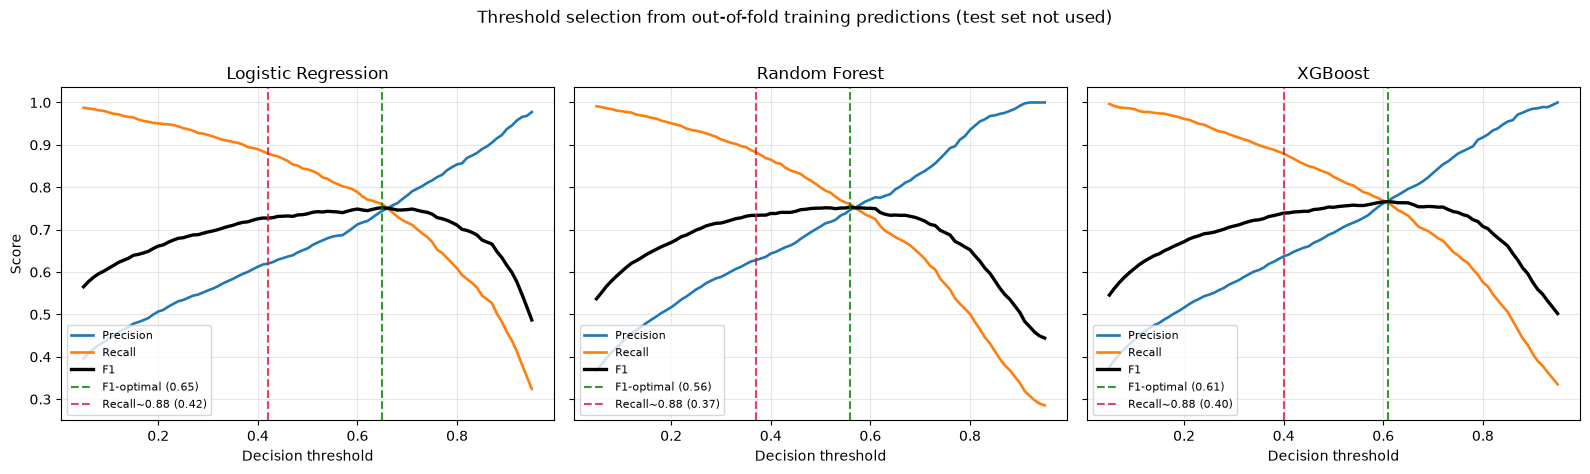

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), sharey=True)

for ax, (name, info) in zip(axes, thresholds.items()):
    curve = info['curve']
    ax.plot(curve['Threshold'], curve['Precision'], label='Precision', linewidth=1.9)
    ax.plot(curve['Threshold'], curve['Recall'],    label='Recall',    linewidth=1.9)
    ax.plot(curve['Threshold'], curve['F1'],        label='F1',        linewidth=2.4, color='black')

    ax.axvline(info['f1'], linestyle='--', alpha=0.8, color='green',
               label=f"F1-optimal ({info['f1']:.2f})")
    ax.axvline(info['recall'], linestyle='--', alpha=0.8, color='crimson',
               label=f"Recall~{TARGET_RECALL:.2f} ({info['recall']:.2f})")

    ax.set_title(name)
    ax.set_xlabel('Decision threshold')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc='lower left')

axes[0].set_ylabel('Score')
fig.suptitle('Threshold selection from out-of-fold training predictions (test set not used)', y=1.02)
plt.tight_layout()
plt.show()

# 8. Final evaluation on the test set

## 8.1 Test-set metrics

In [65]:
def evaluate_on_test(fitted_search, name, threshold):
    """Single, final evaluation. The pipeline applies the same preprocessing it learned on train."""
    model = fitted_search.best_estimator_               # already refit on the full training set
    proba = model.predict_proba(X_test)[:, 1]           # raw X_test -> pipeline transforms it
    pred  = (proba >= threshold).astype(int)
    y_te  = y_test['Churn']

    return {
        'Threshold':           threshold,
        'ROC-AUC':             roc_auc_score(y_te, proba),
        'Accuracy':            accuracy_score(y_te, pred),
        'Precision (Churn=1)': precision_score(y_te, pred, pos_label=1),
        'Recall (Churn=1)':    recall_score(y_te, pred, pos_label=1),
        'F1 (Churn=1)':        f1_score(y_te, pred, pos_label=1),
    }, pred, proba


test_results, test_preds, test_probas = {}, {}, {}

for name, s in searches.items():
    t = thresholds[name]['f1']                          # F1-optimal threshold from section 7
    res, pred, proba = evaluate_on_test(s, name, t)
    test_results[name], test_preds[name], test_probas[name] = res, pred, proba

    print(f"===== {name}  (threshold = {t:.2f}, selected on training data) =====")
    print(classification_report(y_test['Churn'], pred, digits=3))
    print("Confusion matrix  [[TN FP] [FN TP]]:")
    print(confusion_matrix(y_test['Churn'], pred))
    print(f"ROC-AUC: {res['ROC-AUC']:.4f}\n")

test_summary = pd.DataFrame(test_results).T
print("===== TEST-SET COMPARISON (F1-optimal thresholds) =====")
print(test_summary.round(4))

===== Logistic Regression  (threshold = 0.65, selected on training data) =====
              precision    recall  f1-score   support

           0      0.915     0.899     0.907       927
           1      0.756     0.791     0.773       368

    accuracy                          0.868      1295
   macro avg      0.836     0.845     0.840      1295
weighted avg      0.870     0.868     0.869      1295

Confusion matrix  [[TN FP] [FN TP]]:
[[833  94]
 [ 77 291]]
ROC-AUC: 0.9407

===== Random Forest  (threshold = 0.56, selected on training data) =====
              precision    recall  f1-score   support

           0      0.920     0.899     0.909       927
           1      0.759     0.804     0.781       368

    accuracy                          0.872      1295
   macro avg      0.840     0.851     0.845      1295
weighted avg      0.875     0.872     0.873      1295

Confusion matrix  [[TN FP] [FN TP]]:
[[833  94]
 [ 72 296]]
ROC-AUC: 0.9454

===== XGBoost  (threshold = 0.61, select

## 8.2 The same models at the recall-oriented threshold

In [66]:
recall_results = {}
for name, s in searches.items():
    t = thresholds[name]['recall']
    res, _, _ = evaluate_on_test(s, name, t)
    recall_results[name] = res

recall_summary = pd.DataFrame(recall_results).T
print("===== TEST-SET COMPARISON (recall-oriented thresholds) =====")
print(recall_summary.round(4))

===== TEST-SET COMPARISON (recall-oriented thresholds) =====
                     Threshold  ROC-AUC  Accuracy  Precision (Churn=1)  \
Logistic Regression       0.42   0.9407    0.8301               0.6423   
Random Forest             0.37   0.9454    0.8394               0.6527   
XGBoost                   0.40   0.9491    0.8371               0.6542   

                     Recall (Churn=1)  F1 (Churn=1)  
Logistic Regression            0.9076        0.7523  
Random Forest                  0.9293        0.7668  
XGBoost                        0.9049        0.7594  


## 8.3 Training vs. test performance

In [67]:
generalisation = pd.DataFrame({
    name: {
        'CV ROC-AUC (tuned)': searches[name].best_score_,
        'Test ROC-AUC':       test_results[name]['ROC-AUC'],
        'Gap (test - CV)':    test_results[name]['ROC-AUC'] - searches[name].best_score_,
    } for name in searches
}).T
print(generalisation.round(4))

                     CV ROC-AUC (tuned)  Test ROC-AUC  Gap (test - CV)
Logistic Regression              0.9211        0.9407           0.0196
Random Forest                    0.9240        0.9454           0.0214
XGBoost                          0.9311        0.9491           0.0181


## 8.4 ROC and precision-recall curves

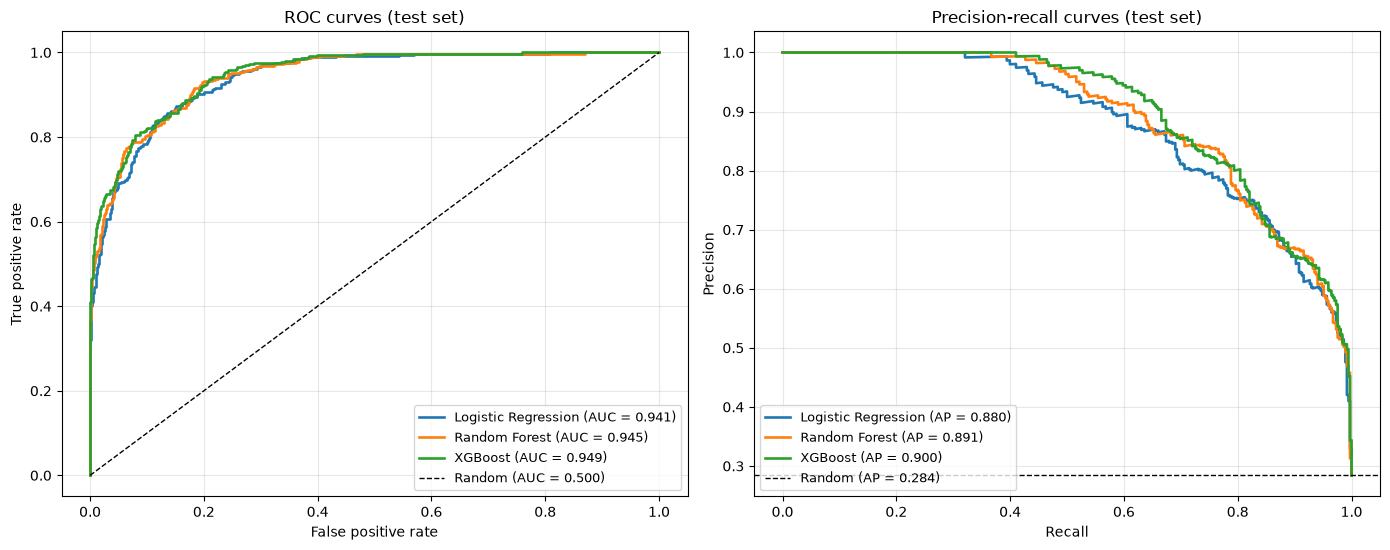

In [68]:
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.6))

for name in searches:
    proba = test_probas[name]

    fpr, tpr, _ = roc_curve(y_test['Churn'], proba)
    ax1.plot(fpr, tpr, linewidth=1.9,
             label=f"{name} (AUC = {test_results[name]['ROC-AUC']:.3f})")

    prec, rec, _ = precision_recall_curve(y_test['Churn'], proba)
    ap = average_precision_score(y_test['Churn'], proba)
    ax2.plot(rec, prec, linewidth=1.9, label=f"{name} (AP = {ap:.3f})")

ax1.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.500)')
ax1.set_xlabel('False positive rate')
ax1.set_ylabel('True positive rate')
ax1.set_title('ROC curves (test set)')
ax1.legend(loc='lower right', fontsize=9)
ax1.grid(alpha=0.3)

churn_rate = y_test['Churn'].mean()
ax2.axhline(churn_rate, linestyle='--', color='k', linewidth=1,
            label=f'Random (AP = {churn_rate:.3f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-recall curves (test set)')
ax2.legend(loc='lower left', fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8.5 Confusion matrices

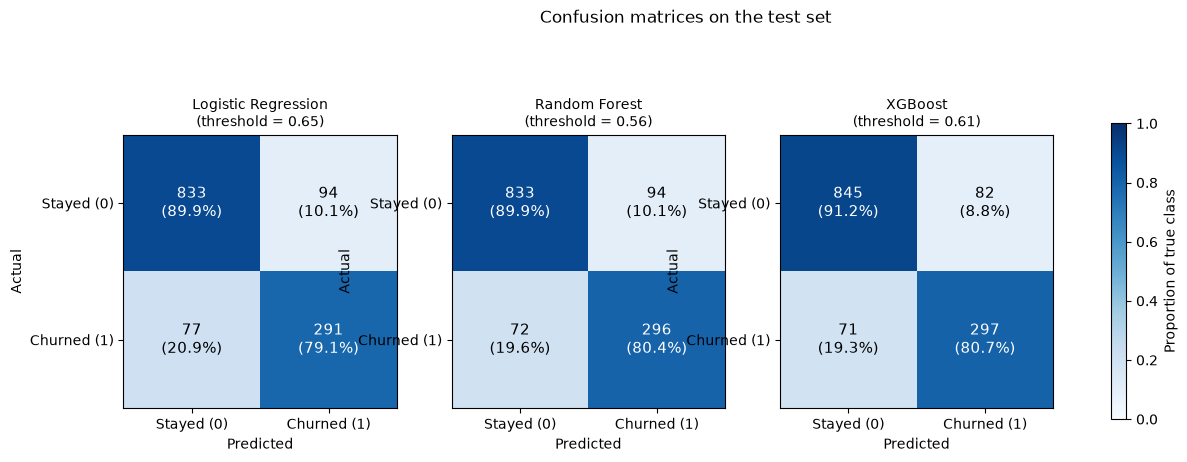

In [69]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
labels = ['Stayed (0)', 'Churned (1)']

for ax, name in zip(axes, searches):
    cm = confusion_matrix(y_test['Churn'], test_preds[name])
    cm_norm = cm / cm.sum(axis=1, keepdims=True)      # row-normalised: recall per true class

    im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)

    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]}\n({cm_norm[i, j]:.1%})",
                    ha='center', va='center', fontsize=11,
                    color='white' if cm_norm[i, j] > 0.5 else 'black')

    ax.set_xticks([0, 1]); ax.set_xticklabels(labels)
    ax.set_yticks([0, 1]); ax.set_yticklabels(labels)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f"{name}\n(threshold = {thresholds[name]['f1']:.2f})", fontsize=10)

fig.colorbar(im, ax=axes, shrink=0.8, label='Proportion of true class')
fig.suptitle('Confusion matrices on the test set', y=1.04)
plt.show()

## 8.6 Final metric comparison

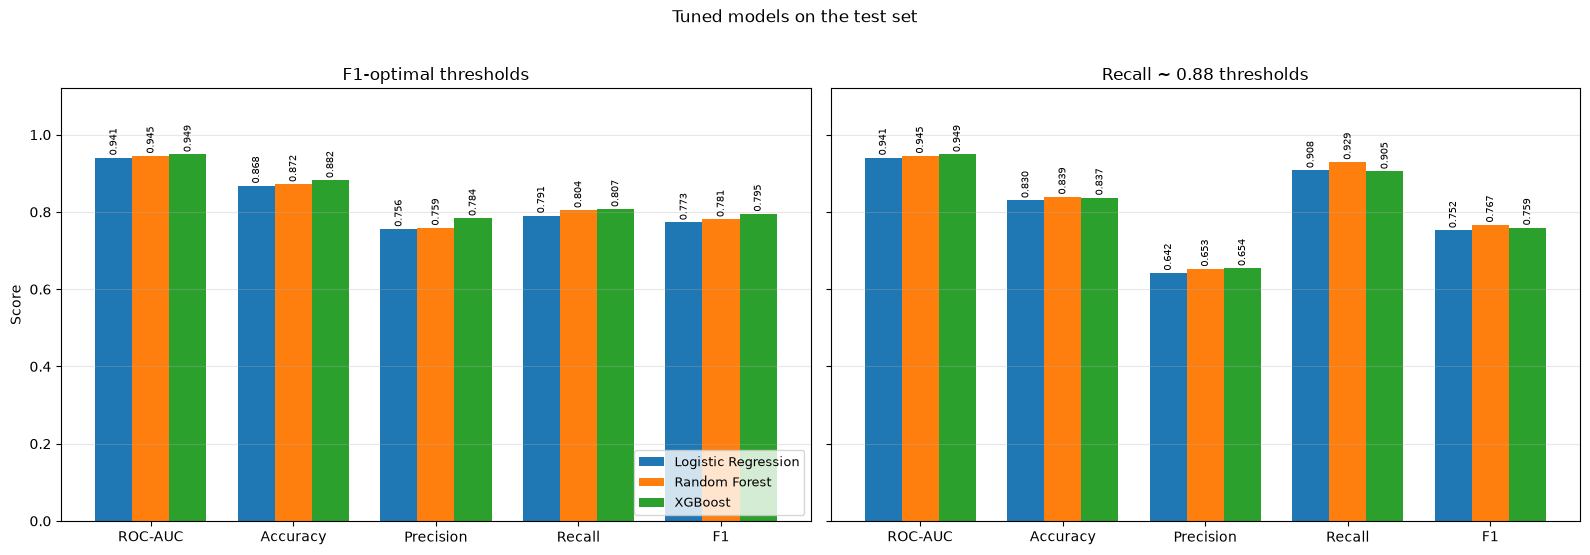

In [70]:
metrics_to_plot = ['ROC-AUC', 'Accuracy', 'Precision (Churn=1)', 'Recall (Churn=1)', 'F1 (Churn=1)']
short = ['ROC-AUC', 'Accuracy', 'Precision', 'Recall', 'F1']

fig, axes = plt.subplots(1, 2, figsize=(16, 5.4), sharey=True)
panels = [(test_summary,   'F1-optimal thresholds'),
          (recall_summary, f'Recall ~ {TARGET_RECALL:.2f} thresholds')]

x = np.arange(len(metrics_to_plot))
width = 0.26

for ax, (summary, title) in zip(axes, panels):
    for i, name in enumerate(summary.index):
        vals = [summary.loc[name, m] for m in metrics_to_plot]
        bars = ax.bar(x + (i - 1) * width, vals, width, label=name)
        for b, v in zip(bars, vals):
            ax.text(b.get_x() + b.get_width() / 2, v + 0.012, f"{v:.3f}",
                    ha='center', fontsize=7.5, rotation=90)

    ax.set_xticks(x); ax.set_xticklabels(short)
    ax.set_ylim(0, 1.12)
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.3)

axes[0].set_ylabel('Score')
axes[0].legend(loc='lower right', fontsize=9)
fig.suptitle('Tuned models on the test set', y=1.02)
plt.tight_layout()
plt.show()

## 8.7 Model selection

The best model is selected by **test-set ROC-AUC**, the threshold-independent metric used throughout.
The selection is reported rather than used to make further adjustments — tuning anything after this
point would turn the test set into a validation set and invalidate the estimate.

In [71]:
best_model_name = test_summary['ROC-AUC'].idxmax()
best_search     = searches[best_model_name]
best_threshold  = thresholds[best_model_name]['f1']

print("=" * 62)
print(f"SELECTED MODEL: {best_model_name}")
print("=" * 62)
print(f"Test ROC-AUC  : {test_results[best_model_name]['ROC-AUC']:.4f}")
print(f"Test F1       : {test_results[best_model_name]['F1 (Churn=1)']:.4f}")
print(f"Test Precision: {test_results[best_model_name]['Precision (Churn=1)']:.4f}")
print(f"Test Recall   : {test_results[best_model_name]['Recall (Churn=1)']:.4f}")
print(f"Test Accuracy : {test_results[best_model_name]['Accuracy']:.4f}")
print(f"Threshold     : {best_threshold:.2f}  (selected on training data)")
print()
print("Hyperparameters:")
for k, v in best_search.best_params_.items():
    print(f"    {k.replace('classifier__', '')}: {v}")

final_model = best_search.best_estimator_     # full pipeline: preprocessing + classifier

SELECTED MODEL: XGBoost
Test ROC-AUC  : 0.9491
Test F1       : 0.7952
Test Precision: 0.7836
Test Recall   : 0.8071
Test Accuracy : 0.8819
Threshold     : 0.61  (selected on training data)

Hyperparameters:
    subsample: 0.8
    reg_lambda: 1.0
    n_estimators: 600
    min_child_weight: 1
    max_depth: 4
    learning_rate: 0.01
    colsample_bytree: 0.6


## 8.8 Feature importance of the selected model

Top 15 features - XGBoost
                          Feature  Importance
          Contract_Month-to-Month      0.2442
                Contract_Two Year      0.1027
                Contract_One Year      0.0771
                  Online Security      0.0483
        Internet Type_Fiber Optic      0.0470
                 Tenure in Months      0.0450
              Number of Referrals      0.0383
             Premium Tech Support      0.0371
             Number of Dependents      0.0339
Internet Type_No Internet Service      0.0271
                 Internet Service      0.0220
       Payment Method_Credit Card      0.0216
                   Monthly Charge      0.0204
            Local_Churn_KNN_Score      0.0195
                              Age      0.0180


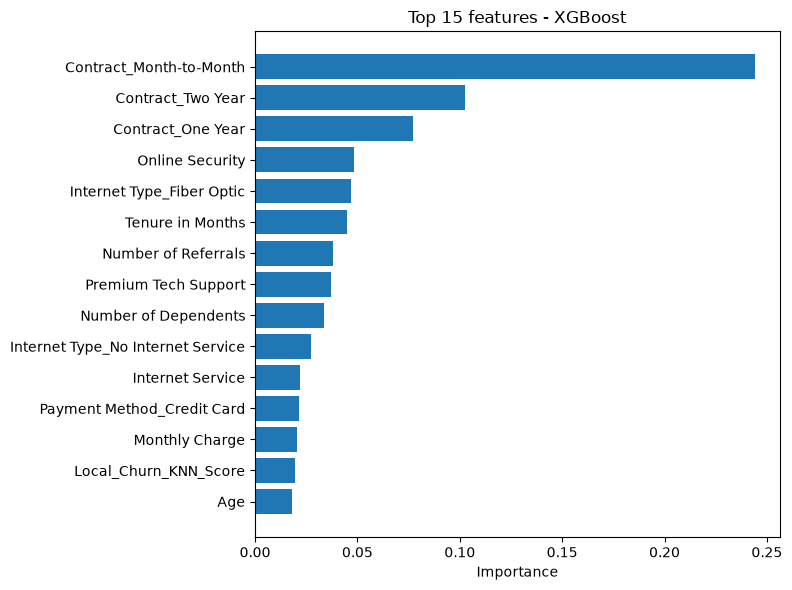

In [72]:
feature_names = final_model.named_steps['preprocess'].get_feature_names_out()
feature_names = [n.split('__', 1)[1] if '__' in n else n for n in feature_names]
clf = final_model.named_steps['classifier']

if hasattr(clf, 'feature_importances_'):
    imp = pd.DataFrame({'Feature': feature_names,
                        'Importance': clf.feature_importances_})
    label = 'Importance'
else:
    imp = pd.DataFrame({'Feature': feature_names,
                        'Coefficient': clf.coef_[0],
                        'Importance': np.abs(clf.coef_[0])})
    label = 'Importance'

imp = imp.sort_values(label, ascending=False).reset_index(drop=True)
print(f"Top 15 features - {best_model_name}")
print(imp.head(15).round(4).to_string(index=False))

top = imp.head(15).iloc[::-1]
plt.figure(figsize=(8, 6))
plt.barh(top['Feature'], top[label])
plt.xlabel(label)
plt.title(f'Top 15 features - {best_model_name}')
plt.tight_layout()
plt.show()